In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision
import torch
import math
import matplotlib.pyplot as plt
import numpy as np
import time
from model import FlowMatchingModel
from train import show_tensor_image,train

In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install kaggle

In [5]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/197604.jpg  
  inflating: img_align_celeba/img_align_celeba/197605.jpg  
  inflating: img_align_celeba/img_align_celeba/197606.jpg  
  inflating: img_align_celeba/img_align_celeba/197607.jpg  
  inflating: img_align_celeba/img_align_celeba/197608.jpg  
  inflating: img_align_celeba/img_align_celeba/197609.jpg  
  inflating: img_align_celeba/img_align_celeba/197610.jpg  
  inflating: img_align_celeba/img_align_celeba/197611.jpg  
  inflating: img_align_celeba/img_align_celeba/197612.jpg  
  inflating: img_align_celeba/img_align_celeba/197613.jpg  
  inflating: img_align_celeba/img_align_celeba/197614.jpg  
  inflating: img_align_celeba/img_align_celeba/197615.jpg  
  inflating: img_align_celeba/img_align_celeba/197616.jpg  
  inflating: img_align_celeba/img_align_celeba/197617.jpg  
  inflating: img_align_celeba/img_align_celeba/197618.jpg  
  inflating: img_align_celeba/img_align_celeba/19

In [6]:
!mkdir celeba
!mv celeba-dataset/img_align_celeba celeba/

mv: cannot stat 'celeba-dataset/img_align_celeba': No such file or directory


In [5]:
def load_transformed_dataset():
    data_transforms = [
        transforms.CenterCrop(178),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # Scales data into [0,1]
        transforms.Lambda(lambda t: (t * 2) - 1) # Scale between [-1, 1]
    ]
    data_transform = transforms.Compose(data_transforms)
    dataset = torchvision.datasets.ImageFolder(
            root="../data",
            transform=data_transform
        )
    #dataset = torchvision.datasets.ImageFolder(
    #    root="img_align_celeba",
    #    transform=data_transform
    #)
       #dataset = torchvision.datasets.MNIST(root=".", train=True, transform=data_transform, download=True)
    return dataset

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


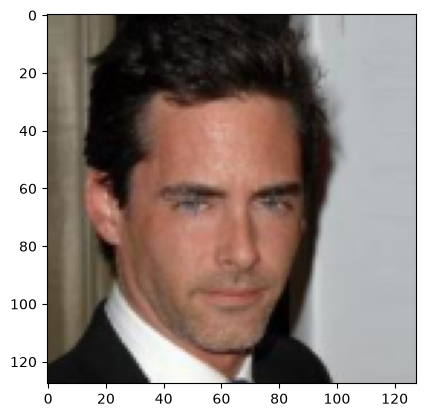

In [7]:
image = next(iter(dataloader))[0].to(device)
t = torch.ones((image.shape[0],), dtype=torch.long) * 150
show_tensor_image(image[0].cpu())

In [42]:
from torchsummary import summary


model = FlowMatchingModel(128,[1,2,2,4,4],time_embed_dim=256,t_bins=400,ending_channels=3,num_blocks=5)
#summary(model,(3,IMG_SIZE,IMG_SIZE))

model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

In [43]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(model)

55057411

In [44]:
model = torch.compile(model)

In [45]:
model.load_state_dict(torch.load(f"models/diffusion__best.pth", weights_only=True))

<All keys matched successfully>

Epoch: 0, Iteration: 0, Loss: 1.3415076732635498, Full Loss:1.3415076732635498, Lr: 4.000000000000001e-06, Time: 1.1906771659851074


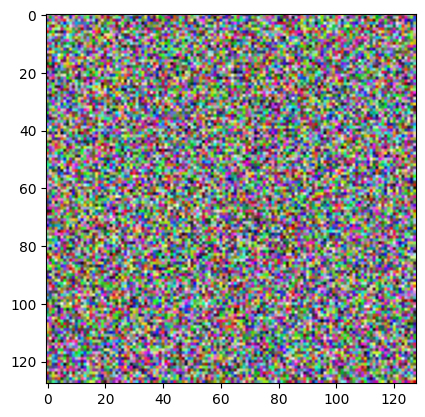

Epoch: 0, Iteration: 100, Loss: 0.5056701898574829, Full Loss:0.5139457583427429, Lr: 0.0001999999998777262, Time: 127.65751218795776
Epoch: 0, Iteration: 200, Loss: 0.19476318359375, Full Loss:0.35514846444129944, Lr: 0.00019999875268771655, Time: 138.8250195980072
Epoch: 0, Iteration: 300, Loss: 0.16106468439102173, Full Loss:0.290668785572052, Lr: 0.00019999506005780873, Time: 141.25823831558228
Epoch: 0, Iteration: 400, Loss: 0.14375008642673492, Full Loss:0.2540307343006134, Lr: 0.00019998892207921708, Time: 144.72134065628052
Epoch: 0, Iteration: 500, Loss: 0.13858115673065186, Full Loss:0.23098687827587128, Lr: 0.0001999803389035603, Time: 146.50947165489197
Epoch: 0, Iteration: 600, Loss: 0.13083897531032562, Full Loss:0.21432335674762726, Lr: 0.00019996931074285753, Time: 146.49572277069092
Epoch: 0, Iteration: 700, Loss: 0.12772859632968903, Full Loss:0.20197029411792755, Lr: 0.00019995583786952352, Time: 144.10163760185242
Epoch: 0, Iteration: 800, Loss: 0.1252206265926361, 

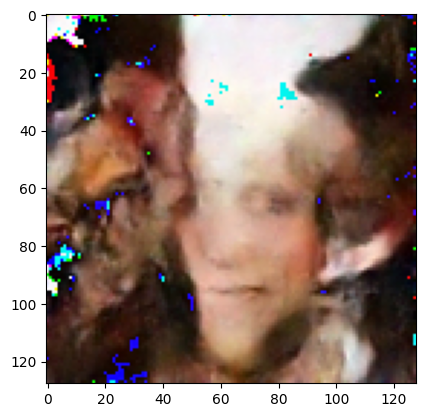

Epoch: 0, Iteration: 1100, Loss: 0.11228074133396149, Full Loss:0.17138497531414032, Lr: 0.00019987750681158415, Time: 144.51914143562317
Epoch: 0, Iteration: 1200, Loss: 0.11129774898290634, Full Loss:0.16638188064098358, Lr: 0.00019985181657459477, Time: 146.91248297691345
Epoch: 0, Iteration: 1300, Loss: 0.11462779343128204, Full Loss:0.16240385174751282, Lr: 0.0001998236845272826, Time: 147.12884211540222
Epoch: 0, Iteration: 1400, Loss: 0.10486767441034317, Full Loss:0.15829704701900482, Lr: 0.0001997931113645577, Time: 145.92619585990906
Epoch: 0, Iteration: 1500, Loss: 0.10747608542442322, Full Loss:0.15491126477718353, Lr: 0.00019976009784162998, Time: 144.84356045722961
Epoch: 0, Iteration: 1600, Loss: 0.10893583297729492, Full Loss:0.15203958749771118, Lr: 0.0001997246447739903, Time: 147.36494851112366
Epoch: 0, Iteration: 1700, Loss: 0.1046546921133995, Full Loss:0.14925388991832733, Lr: 0.0001996867530373906, Time: 147.42260217666626
Epoch: 0, Iteration: 1800, Loss: 0.1045

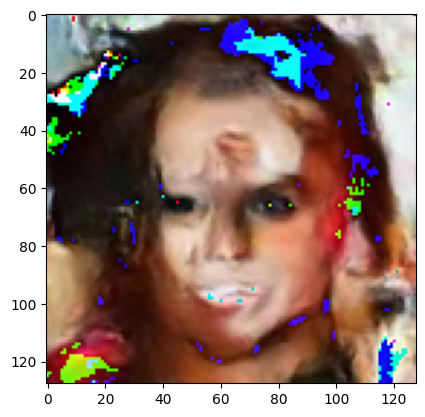

Epoch: 0, Iteration: 2100, Loss: 0.10014999657869339, Full Loss:0.14052504301071167, Lr: 0.00019951081902431033, Time: 147.6278886795044
Epoch: 0, Iteration: 2200, Loss: 0.10315608233213425, Full Loss:0.13882720470428467, Lr: 0.00019946074918672518, Time: 145.56544661521912
Epoch: 0, Iteration: 2300, Loss: 0.10201310366392136, Full Loss:0.13722728192806244, Lr: 0.00019940824719885602, Time: 145.50882744789124
Epoch: 0, Iteration: 2400, Loss: 0.09932675957679749, Full Loss:0.13564875721931458, Lr: 0.00019935331435759252, Time: 147.80563473701477
Epoch: 0, Iteration: 2500, Loss: 0.09966650605201721, Full Loss:0.13421005010604858, Lr: 0.00019929595201987057, Time: 145.75211691856384
Epoch: 0, Iteration: 2600, Loss: 0.10064246505498886, Full Loss:0.13291947543621063, Lr: 0.00019923616160263884, Time: 143.03990077972412
Epoch: 0, Iteration: 2700, Loss: 0.10347450524568558, Full Loss:0.13182932138442993, Lr: 0.00019917394458282374, Time: 144.0254135131836
Epoch: 0, Iteration: 2800, Loss: 0.0

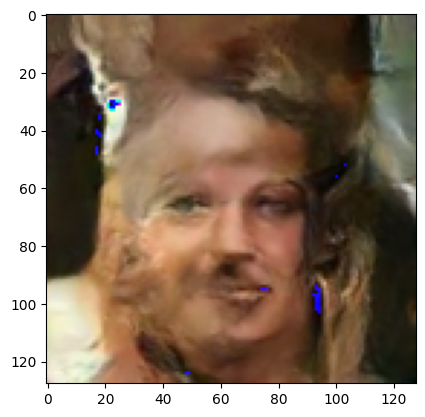

Epoch: 0, Iteration: 3100, Loss: 0.09876716881990433, Full Loss:0.12758496403694153, Lr: 0.00019890084211339446, Time: 145.22701215744019
Epoch: 0, Iteration: 3200, Loss: 0.09641057252883911, Full Loss:0.12661108374595642, Lr: 0.0001988265163311431, Time: 146.45893740653992
Epoch: 0, Iteration: 3300, Loss: 0.09426732361316681, Full Loss:0.12563125789165497, Lr: 0.00019874977406525297, Time: 145.93862318992615
Epoch: 0, Iteration: 3400, Loss: 0.09746068716049194, Full Loss:0.12480296194553375, Lr: 0.00019867061721139036, Time: 143.3467857837677
Epoch: 0, Iteration: 3500, Loss: 0.09461889415979385, Full Loss:0.12394081056118011, Lr: 0.00019858904772486596, Time: 145.2967402935028
Epoch: 0, Iteration: 3600, Loss: 0.09394659847021103, Full Loss:0.12310786545276642, Lr: 0.00019850506762058683, Time: 145.01849627494812
Epoch: 0, Iteration: 3700, Loss: 0.09704466909170151, Full Loss:0.12240363657474518, Lr: 0.00019841867897300627, Time: 147.41795253753662
Epoch: 0, Iteration: 3800, Loss: 0.09

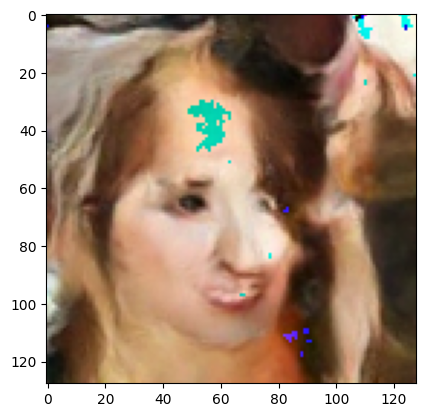

Epoch: 0, Iteration: 4100, Loss: 0.09681804478168488, Full Loss:0.11965274065732956, Lr: 0.000198049082519952, Time: 147.23783540725708
Epoch: 0, Iteration: 4200, Loss: 0.09377754479646683, Full Loss:0.11903680860996246, Lr: 0.0001979506843531207, Time: 147.07165026664734
Epoch: 0, Iteration: 4300, Loss: 0.09257419407367706, Full Loss:0.11842154711484909, Lr: 0.00019784989133721063, Time: 146.83903670310974
Epoch: 0, Iteration: 4400, Loss: 0.09303572028875351, Full Loss:0.11784473061561584, Lr: 0.00019774670596198318, Time: 146.74696969985962
Epoch: 0, Iteration: 4500, Loss: 0.09304716438055038, Full Loss:0.11729379743337631, Lr: 0.00019764113077629499, Time: 147.31601452827454
Epoch: 0, Iteration: 4600, Loss: 0.09305153787136078, Full Loss:0.11676689982414246, Lr: 0.00019753316838803516, Time: 147.43355178833008
Epoch: 0, Iteration: 4700, Loss: 0.09502895176410675, Full Loss:0.11630449444055557, Lr: 0.00019742282146406089, Time: 146.87244772911072
Epoch: 0, Iteration: 4800, Loss: 0.09

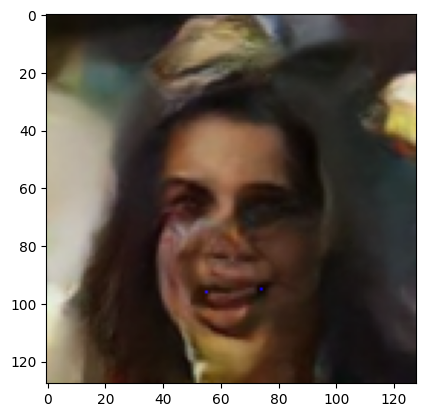

Epoch: 0, Iteration: 5100, Loss: 0.0945422351360321, Full Loss:0.1144491657614708, Lr: 0.0001969576438083132, Time: 147.56808233261108
Epoch: 0, Iteration: 5200, Loss: 0.0885082334280014, Full Loss:0.11395039409399033, Lr: 0.00019683541626781194, Time: 147.5629734992981
Epoch: 0, Iteration: 5300, Loss: 0.0937984436750412, Full Loss:0.11357025057077408, Lr: 0.0001967108214272767, Time: 147.2785210609436
Epoch: 0, Iteration: 5400, Loss: 0.08923301845788956, Full Loss:0.11311964690685272, Lr: 0.00019658386236441494, Time: 147.01685905456543
Epoch: 0, Iteration: 5500, Loss: 0.0927821546792984, Full Loss:0.11274992674589157, Lr: 0.0001964545422153345, Time: 146.90135431289673
Epoch: 0, Iteration: 5600, Loss: 0.09255483746528625, Full Loss:0.11238937079906464, Lr: 0.00019632286417446587, Time: 147.04902505874634
Epoch: 0, Iteration: 5700, Loss: 0.09578309953212738, Full Loss:0.1120980903506279, Lr: 0.00019618883149448392, Time: 147.00726413726807
Epoch: 0, Iteration: 5800, Loss: 0.0888127908

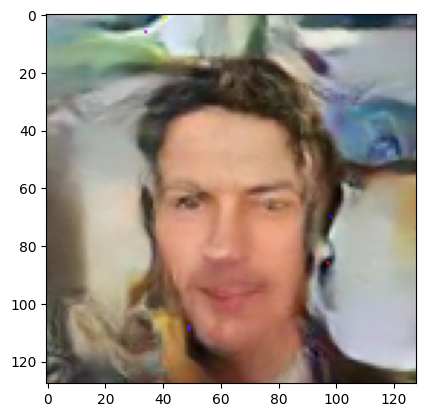

Epoch: 0, Iteration: 6100, Loss: 0.08977124840021133, Full Loss:0.11059800535440445, Lr: 0.00019562922147091534, Time: 147.13938856124878
Epoch: 0, Iteration: 6200, Loss: 0.09021595865488052, Full Loss:0.11026930809020996, Lr: 0.00019548346641832135, Time: 147.40912866592407
Epoch: 0, Iteration: 6300, Loss: 0.09142464399337769, Full Loss:0.10997024178504944, Lr: 0.00019533537746118596, Time: 147.03635907173157
Epoch: 1, Iteration: 0, Loss: 0.08893121033906937, Full Loss:0.10986723005771637, Lr: 0.00019528899655553466, Time: 58.17628860473633


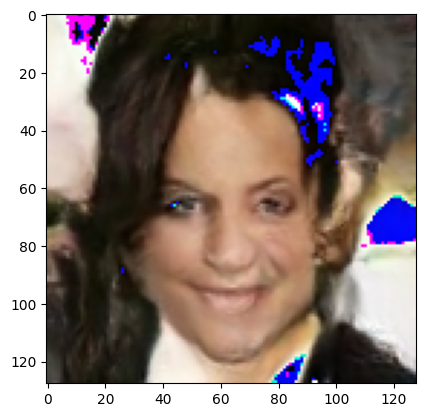

Epoch: 1, Iteration: 100, Loss: 0.08959837257862091, Full Loss:0.10955210030078888, Lr: 0.00019513785572726852, Time: 147.47287607192993
Epoch: 1, Iteration: 200, Loss: 0.08698548376560211, Full Loss:0.10920663923025131, Lr: 0.00019498438953164098, Time: 146.38163709640503
Epoch: 1, Iteration: 300, Loss: 0.09073617309331894, Full Loss:0.10892811417579651, Lr: 0.00019482860175953166, Time: 146.6949601173401
Epoch: 1, Iteration: 400, Loss: 0.09065771102905273, Full Loss:0.10865671932697296, Lr: 0.0001946704962591672, Time: 147.17496275901794
Epoch: 1, Iteration: 500, Loss: 0.08973517268896103, Full Loss:0.10837976634502411, Lr: 0.00019451007693602605, Time: 146.65670442581177
Epoch: 1, Iteration: 600, Loss: 0.08855127543210983, Full Loss:0.1080937311053276, Lr: 0.00019434734775274214, Time: 146.76759481430054
Epoch: 1, Iteration: 700, Loss: 0.08788847178220749, Full Loss:0.10780639201402664, Lr: 0.00019418231272900688, Time: 146.8087420463562
Epoch: 1, Iteration: 800, Loss: 0.08853527158

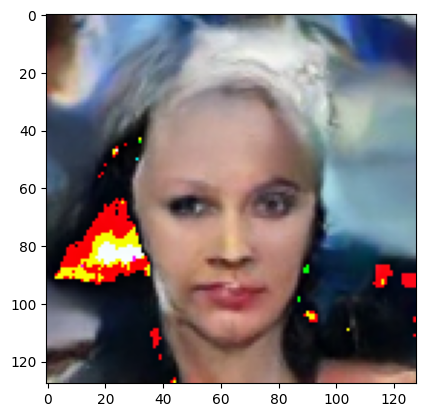

Epoch: 1, Iteration: 1100, Loss: 0.0901620090007782, Full Loss:0.10680258274078369, Lr: 0.00019349919661479462, Time: 147.19934368133545
Epoch: 1, Iteration: 1200, Loss: 0.09158576279878616, Full Loss:0.1066005602478981, Lr: 0.00019332269467415826, Time: 146.79237461090088
Epoch: 1, Iteration: 1300, Loss: 0.08595344424247742, Full Loss:0.1063300296664238, Lr: 0.00019314391220376847, Time: 146.34406185150146
Epoch: 1, Iteration: 1400, Loss: 0.08641202747821808, Full Loss:0.10607242584228516, Lr: 0.00019296285361986045, Time: 146.68385410308838
Epoch: 1, Iteration: 1500, Loss: 0.08646318316459656, Full Loss:0.10582204908132553, Lr: 0.00019277952339489355, Time: 147.2337625026703
Epoch: 1, Iteration: 1600, Loss: 0.08702252060174942, Full Loss:0.10558503866195679, Lr: 0.00019259392605744038, Time: 147.12526679039001
Epoch: 1, Iteration: 1700, Loss: 0.08628929406404495, Full Loss:0.10534480214118958, Lr: 0.0001924060661920752, Time: 146.62060379981995
Epoch: 1, Iteration: 1800, Loss: 0.0869

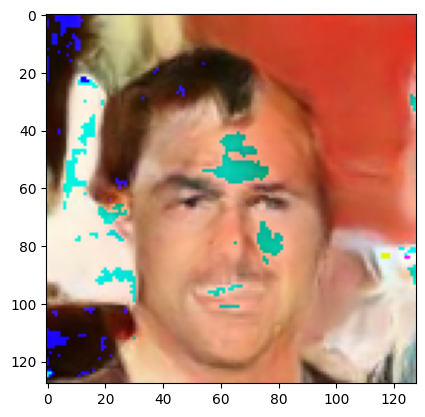

Epoch: 1, Iteration: 2100, Loss: 0.08795148134231567, Full Loss:0.10448382049798965, Lr: 0.00019163209509665506, Time: 146.942528963089
Epoch: 1, Iteration: 2200, Loss: 0.08526254445314407, Full Loss:0.10425853729248047, Lr: 0.00019143299331239496, Time: 146.90446162223816
Epoch: 1, Iteration: 2300, Loss: 0.08555147051811218, Full Loss:0.10404182970523834, Lr: 0.00019123165767726355, Time: 146.67858910560608
Epoch: 1, Iteration: 2400, Loss: 0.08557602763175964, Full Loss:0.10383035242557526, Lr: 0.00019102809316459812, Time: 146.7034776210785
Epoch: 1, Iteration: 2500, Loss: 0.08677779138088226, Full Loss:0.10363726317882538, Lr: 0.0001908223048027932, Time: 146.84505677223206
Epoch: 1, Iteration: 2600, Loss: 0.08448433876037598, Full Loss:0.10342284291982651, Lr: 0.0001906142976751761, Time: 146.4681956768036
Epoch: 1, Iteration: 2700, Loss: 0.08955953270196915, Full Loss:0.10326934605836868, Lr: 0.0001904040769198816, Time: 146.66325187683105
Epoch: 1, Iteration: 2800, Loss: 0.084374

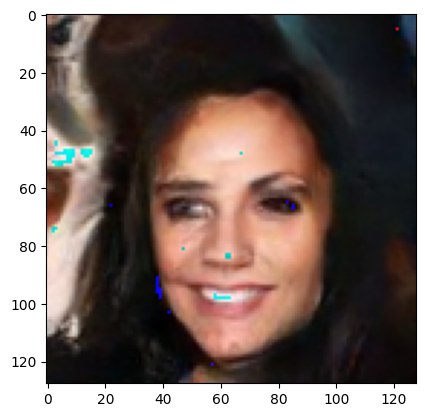

Epoch: 1, Iteration: 3100, Loss: 0.08739368617534637, Full Loss:0.10252271592617035, Lr: 0.0001895411622957356, Time: 146.26481986045837
Epoch: 1, Iteration: 3200, Loss: 0.08879543095827103, Full Loss:0.10237870365381241, Lr: 0.00018931995238337187, Time: 146.56896305084229
Epoch: 1, Iteration: 3300, Loss: 0.08817592263221741, Full Loss:0.10223124921321869, Lr: 0.00018909656081589132, Time: 146.57720708847046
Epoch: 1, Iteration: 3400, Loss: 0.08540992438793182, Full Loss:0.10205840319395065, Lr: 0.00018887099311145088, Time: 146.59606075286865
Epoch: 1, Iteration: 3500, Loss: 0.0857066884636879, Full Loss:0.10189208388328552, Lr: 0.00018864325484196177, Time: 146.7576026916504
Epoch: 1, Iteration: 3600, Loss: 0.08666402101516724, Full Loss:0.10173877328634262, Lr: 0.00018841335163295196, Time: 147.1999180316925
Epoch: 1, Iteration: 3700, Loss: 0.08646716922521591, Full Loss:0.10158653557300568, Lr: 0.0001881812891634271, Time: 146.9527666568756
Epoch: 1, Iteration: 3800, Loss: 0.08521

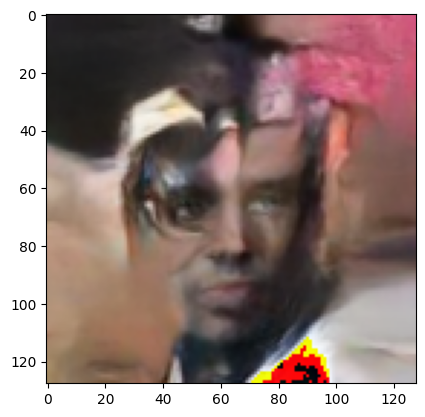

Epoch: 1, Iteration: 4100, Loss: 0.08375861495733261, Full Loss:0.10093549638986588, Lr: 0.0001872315621241199, Time: 147.15358519554138
Epoch: 1, Iteration: 4200, Loss: 0.08498967438936234, Full Loss:0.10078408569097519, Lr: 0.00018698879039893293, Time: 147.10350060462952
Epoch: 1, Iteration: 4300, Loss: 0.08474411070346832, Full Loss:0.10063321888446808, Lr: 0.0001867438946023499, Time: 146.98054575920105
Epoch: 1, Iteration: 4400, Loss: 0.0856495276093483, Full Loss:0.10049360990524292, Lr: 0.00018649688078371915, Time: 147.1555986404419
Epoch: 1, Iteration: 4500, Loss: 0.08627448976039886, Full Loss:0.10036233812570572, Lr: 0.00018624775504470805, Time: 147.09739089012146
Epoch: 1, Iteration: 4600, Loss: 0.0858049988746643, Full Loss:0.1002291589975357, Lr: 0.00018599652353915182, Time: 147.20254516601562
Epoch: 1, Iteration: 4700, Loss: 0.08384016156196594, Full Loss:0.10008061677217484, Lr: 0.00018574319247290197, Time: 147.08273267745972
Epoch: 1, Iteration: 4800, Loss: 0.08563

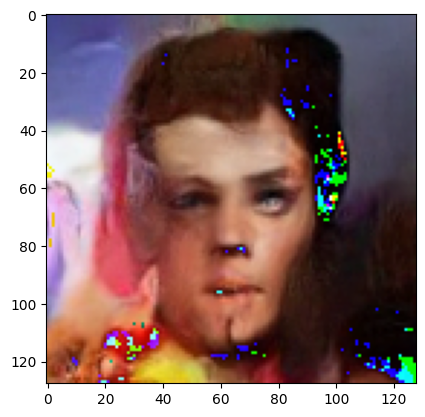

Epoch: 1, Iteration: 5100, Loss: 0.08635503798723221, Full Loss:0.09959450364112854, Lr: 0.0001847089985299355, Time: 147.12635278701782
Epoch: 1, Iteration: 5200, Loss: 0.08375108987092972, Full Loss:0.09945711493492126, Lr: 0.00018444526455774815, Time: 146.87299728393555
Epoch: 1, Iteration: 5300, Loss: 0.08176227658987045, Full Loss:0.09930499643087387, Lr: 0.00018417946934363882, Time: 146.67862939834595
Epoch: 1, Iteration: 5400, Loss: 0.08658876270055771, Full Loss:0.09919660538434982, Lr: 0.00018391161945320768, Time: 147.00601243972778
Epoch: 1, Iteration: 5500, Loss: 0.08422987163066864, Full Loss:0.09907011687755585, Lr: 0.00018364172150280885, Time: 147.15592122077942
Epoch: 1, Iteration: 5600, Loss: 0.08372237533330917, Full Loss:0.09894149005413055, Lr: 0.00018336978215938708, Time: 146.64118719100952
Epoch: 1, Iteration: 5700, Loss: 0.08298764377832413, Full Loss:0.0988088846206665, Lr: 0.0001830958081403131, Time: 147.2652382850647
Epoch: 1, Iteration: 5800, Loss: 0.083

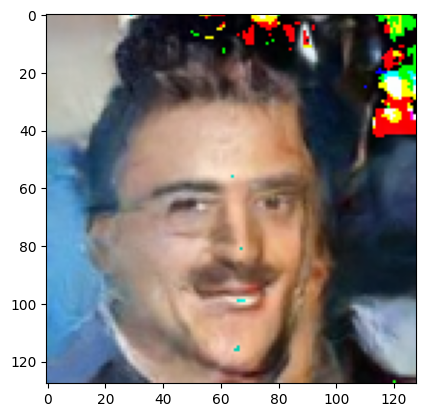

Epoch: 1, Iteration: 6100, Loss: 0.08448109030723572, Full Loss:0.0983314961194992, Lr: 0.00018197970141048956, Time: 147.0038504600525
Epoch: 1, Iteration: 6200, Loss: 0.08613124489784241, Full Loss:0.0982341468334198, Lr: 0.00018169565652693782, Time: 146.64030599594116
Epoch: 1, Iteration: 6300, Loss: 0.08557940274477005, Full Loss:0.09813395887613297, Lr: 0.00018140961832152375, Time: 146.9728443622589
Epoch: 2, Iteration: 0, Loss: 0.08590458333492279, Full Loss:0.09810402244329453, Lr: 0.00018132054283721813, Time: 53.74193620681763


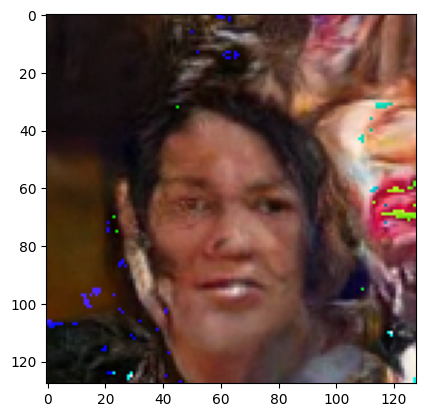

Epoch: 2, Iteration: 100, Loss: 0.0841875970363617, Full Loss:0.09799498319625854, Lr: 0.00018103190407850212, Time: 146.88797736167908
Epoch: 2, Iteration: 200, Loss: 0.08547563850879669, Full Loss:0.09789765626192093, Lr: 0.00018074128839375373, Time: 146.42158937454224
Epoch: 2, Iteration: 300, Loss: 0.0823063850402832, Full Loss:0.09777738153934479, Lr: 0.00018044870296168156, Time: 145.89077615737915
Epoch: 2, Iteration: 400, Loss: 0.08345978707075119, Full Loss:0.09766778349876404, Lr: 0.00018015415500965024, Time: 146.31076288223267
Epoch: 2, Iteration: 500, Loss: 0.08490870147943497, Full Loss:0.09757085144519806, Lr: 0.0001798576518135021, Time: 146.60087203979492
Epoch: 2, Iteration: 600, Loss: 0.08757375925779343, Full Loss:0.09749546647071838, Lr: 0.00017955920069737742, Time: 146.59854698181152
Epoch: 2, Iteration: 700, Loss: 0.08518201857805252, Full Loss:0.09740332514047623, Lr: 0.0001792588090335333, Time: 146.84960794448853
Epoch: 2, Iteration: 800, Loss: 0.08519664406

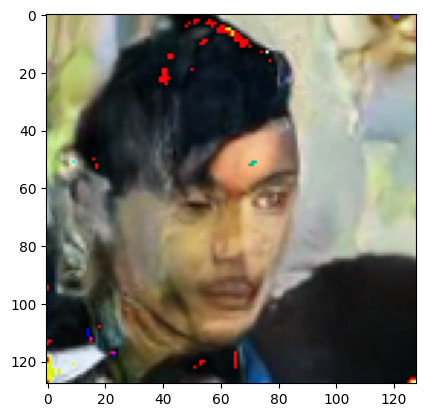

Epoch: 2, Iteration: 1100, Loss: 0.08170563727617264, Full Loss:0.09700092673301697, Lr: 0.00017803798601997005, Time: 146.89109826087952
Epoch: 2, Iteration: 1200, Loss: 0.08524418622255325, Full Loss:0.09691613167524338, Lr: 0.00017772800387266756, Time: 147.12585186958313
Epoch: 2, Iteration: 1300, Loss: 0.08271857351064682, Full Loss:0.09681444615125656, Lr: 0.00017741612641136484, Time: 146.64664101600647
Epoch: 2, Iteration: 1400, Loss: 0.08221473544836044, Full Loss:0.09671062231063843, Lr: 0.00017710236133997302, Time: 146.50840139389038
Epoch: 2, Iteration: 1500, Loss: 0.08465433865785599, Full Loss:0.09662550687789917, Lr: 0.00017678671640903025, Time: 147.0592863559723
Epoch: 2, Iteration: 1600, Loss: 0.0868140384554863, Full Loss:0.09655673801898956, Lr: 0.00017646919941551075, Time: 147.57035398483276
Epoch: 2, Iteration: 1700, Loss: 0.08389732241630554, Full Loss:0.09646857529878616, Lr: 0.0001761498182026317, Time: 147.86744666099548
Epoch: 2, Iteration: 1800, Loss: 0.08

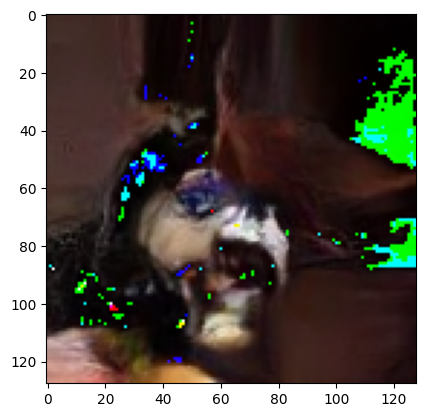

Epoch: 2, Iteration: 2100, Loss: 0.08294327557086945, Full Loss:0.09612145274877548, Lr: 0.00017485380962949457, Time: 147.36880922317505
Epoch: 2, Iteration: 2200, Loss: 0.08577825874090195, Full Loss:0.09605186432600021, Lr: 0.00017452522657296205, Time: 147.72392797470093
Epoch: 2, Iteration: 2300, Loss: 0.08407928794622421, Full Loss:0.09597185254096985, Lr: 0.00017419482731655128, Time: 147.21142482757568
Epoch: 2, Iteration: 2400, Loss: 0.084710031747818, Full Loss:0.09589707851409912, Lr: 0.00017386262002169357, Time: 147.2936680316925
Epoch: 2, Iteration: 2500, Loss: 0.08331871777772903, Full Loss:0.09581413120031357, Lr: 0.00017352861289448196, Time: 147.4649999141693
Epoch: 2, Iteration: 2600, Loss: 0.08541841804981232, Full Loss:0.09574601799249649, Lr: 0.0001731928141854684, Time: 146.98848223686218
Epoch: 2, Iteration: 2700, Loss: 0.08521822839975357, Full Loss:0.09567749500274658, Lr: 0.0001728552321894601, Time: 146.93431401252747
Epoch: 2, Iteration: 2800, Loss: 0.08163

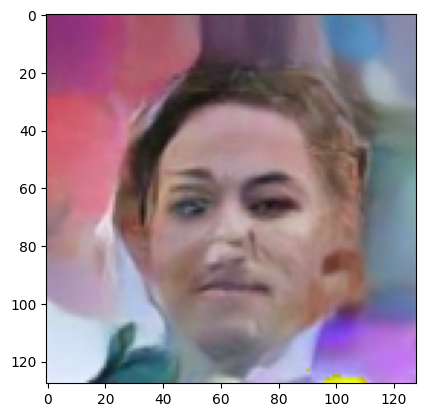

Epoch: 2, Iteration: 3100, Loss: 0.08494315296411514, Full Loss:0.09535843133926392, Lr: 0.00017148723876904767, Time: 146.91330075263977
Epoch: 2, Iteration: 3200, Loss: 0.08163836598396301, Full Loss:0.09527194499969482, Lr: 0.0001711408662946996, Time: 147.17924857139587
Epoch: 2, Iteration: 3300, Loss: 0.08269517868757248, Full Loss:0.09519315510988235, Lr: 0.00017079276122000789, Time: 146.61886858940125


In [ ]:
train(dataloader, 10, model, optimizer, device, print_iterations_steps=100,min_lr=2e-5,max_lr=2e-3,img_size=IMG_SIZE)

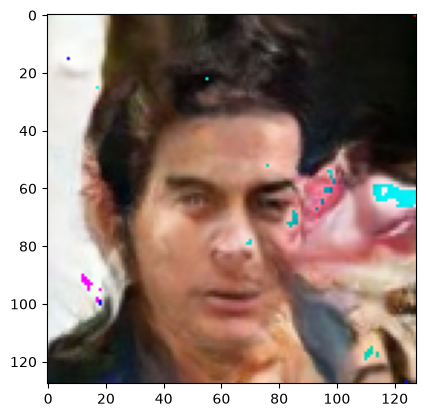

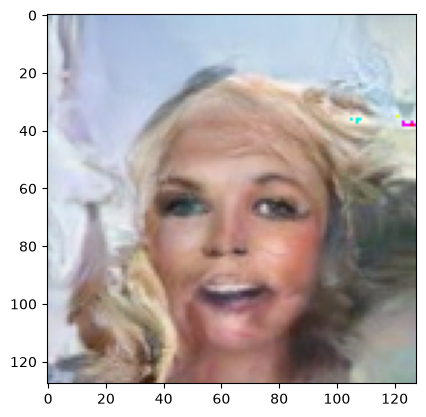

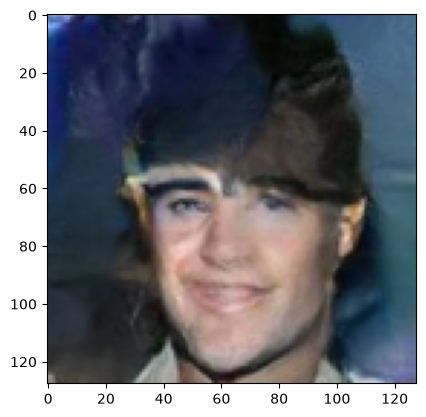

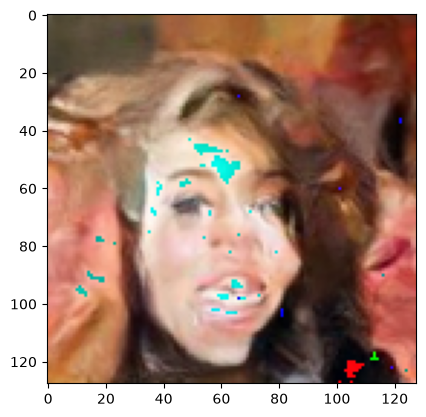

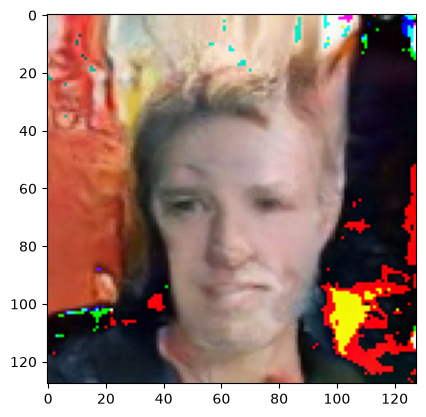

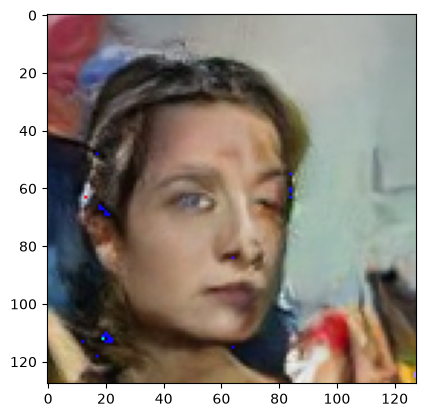

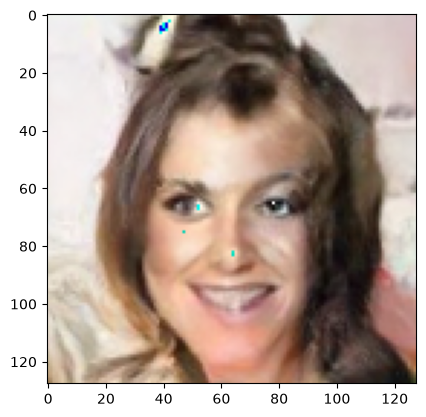

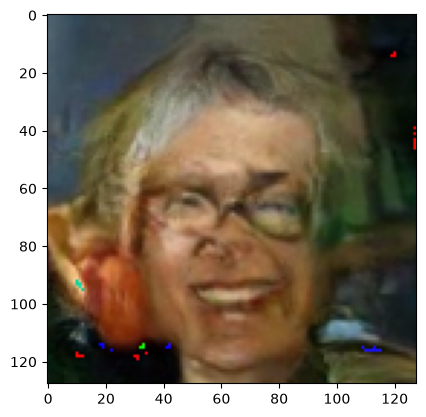

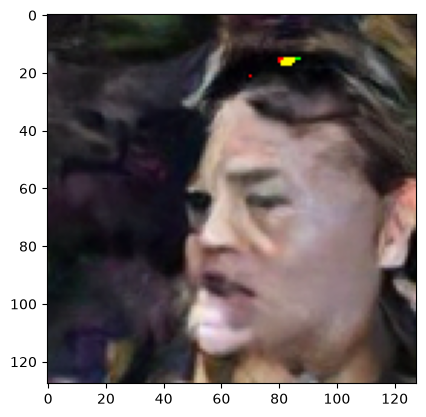

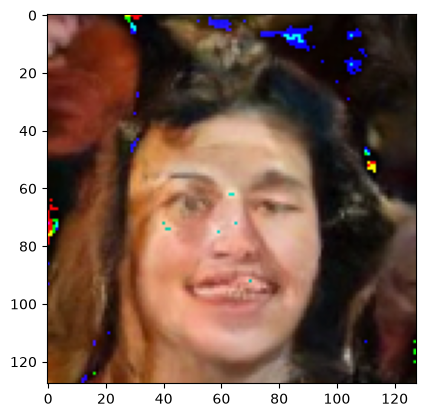

: 

In [ ]:
img_count = 10
model.eval()
with torch.no_grad():
    results = model.sample(IMG_SIZE, num_samples=img_count, device=device,bins=300)
    for i in range(img_count):
        show_tensor_image(results[i].cpu())
        plt.show()
plt.show()
a = model.train()